# Multi-Layer Yield Curve Network Analysis

Merged notebook: **Chapters A–G** from `ycs_multilayer_evolution.ipynb`, continued by **Chapters H–O** from `ycs_multilayer_enhanced.ipynb`. The source notebooks are unchanged.

Each layer is a maturity term (6M, 1Y, 2Y, 5Y, …); nodes are bond issuers. Inter-layer edges connect the same issuer across terms.

## Key Concepts
- **Intra-layer edges**: Correlations between issuers within the same term
- **Inter-layer edges**: Direct connections linking the same issuer across terms
- **Temporal evolution**: Rolling window networks over time for each layer + aggregate multi-layer structure
- **Multi-layer metrics**: Degree centrality, clustering, betweenness accounting for all layers

## Enhanced extensions (Part II)
- Yield curve factor extraction (Nelson-Siegel + PCA)
- Residual-based network construction
- Weighted inter-layer connectivity
- Temporal factor dynamics & regime classification
- Multi-layer community detection with layer awareness
- Stress testing & correlation breakdown detection
- Advanced centrality (tensor-based, spreading dynamics)
- 3D interactive visualization
- Signal subgraph detection

## Contents
1. **Part I** — Multi-layer network evolution (Chapters A–G)
2. **Part II** — Factor models, residuals, and stress (Chapters H–O)
3. **Part III** — Roadmaps and suggestions (from both notebooks)


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import polars as pl
import networkx as nx
from pathlib import Path
import duckdb
from tqdm import tqdm
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
import seaborn as sns
from plotnine import *
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

from tgraphportfolio.analysis.measures import compute_measure, available_measures
from tgraphportfolio.analysis.network import build_corr_nx, pivot_to_wide
from tgraphportfolio.analysis.evolution import (
    EvolutionConfig, CommunityMethod, compute_community_metrics
)
from tgraphportfolio.analysis.yield_curve_factors import (
    fit_nelson_siegel_batch, fit_pca, classify_yield_curve_regimes,
    extract_ns_residuals, compute_factor_trajectories, compute_interlayer_weights
)
from graspologic.embed import AdjacencySpectralEmbed
from sklearn.cluster import KMeans

print(f"Imports successful at {datetime.now()}")


Imports successful at 2026-08-20 00:37:16.190984


# Part I: Multi-Layer Network Evolution

Chapters A–G: load the panel, build intra- and inter-layer networks, and track multiplex structure over rolling windows.


## Chapter A: Data Loading and Exploration

Load zero-coupon yield rates from DuckDB and understand the multi-layer structure.

### Load zero rates from DuckDB


In [2]:
# Connect to DuckDB
db_path = r'D:\data\duckdb\ycs_data.duckdb'
conn = duckdb.connect(db_path, read_only=True)

# Load zero_rates data
df_raw = conn.execute(
    "SELECT * FROM zero_rates ORDER BY date, source"
).pl()

print(f"Loaded {df_raw.height:,} rows, {df_raw.width} columns")
print(f"\nColumns: {df_raw.columns}")
print(f"\nData types:")
print(df_raw.schema)
print(f"\nFirst 10 rows:")
print(df_raw.head(10))

Loaded 111,785 rows, 29 columns

Columns: ['Y000p5', 'Y001p0', 'Y001p5', 'Y002p0', 'Y002p5', 'Y003p0', 'Y003p5', 'Y004p0', 'Y004p5', 'Y005p0', 'Y006p0', 'Y007p0', 'Y008p0', 'Y009p0', 'Y010p0', 'Y011p0', 'Y012p0', 'Y013p0', 'Y014p0', 'Y015p0', 'Y016p0', 'Y017p0', 'Y018p0', 'Y019p0', 'Y020p0', 'Y025p0', 'Y030p0', 'date', 'source']

Data types:
Schema({'Y000p5': Float32, 'Y001p0': Float32, 'Y001p5': Float32, 'Y002p0': Float32, 'Y002p5': Float32, 'Y003p0': Float32, 'Y003p5': Float32, 'Y004p0': Float32, 'Y004p5': Float32, 'Y005p0': Float32, 'Y006p0': Float32, 'Y007p0': Float32, 'Y008p0': Float32, 'Y009p0': Float32, 'Y010p0': Float32, 'Y011p0': Float32, 'Y012p0': Float32, 'Y013p0': Float32, 'Y014p0': Float32, 'Y015p0': Float32, 'Y016p0': Float32, 'Y017p0': Float32, 'Y018p0': Float32, 'Y019p0': Float32, 'Y020p0': Float32, 'Y025p0': Float32, 'Y030p0': Float32, 'date': String, 'source': String})

First 10 rows:
shape: (10, 29)
┌───────────┬───────────┬───────────┬───────────┬───┬──────────┬────

### Reshape wide terms to long format


In [3]:
df_raw = df_raw.unpivot(on=['Y000p5', 'Y001p0', 'Y001p5', 'Y002p0', 'Y002p5', 'Y003p0', 
                   'Y003p5', 'Y004p0', 'Y004p5', 'Y005p0', 'Y006p0', 'Y007p0', 
                   'Y008p0', 'Y009p0', 'Y010p0', 'Y011p0', 'Y012p0', 'Y013p0', 
                   'Y014p0', 'Y015p0', 'Y016p0', 'Y017p0', 'Y018p0', 'Y019p0', 
                   'Y020p0', 'Y025p0', 'Y030p0'], index=['date','source'], variable_name="term", value_name="rate")

### Panel dimensions (sources, terms, dates)


In [4]:
# Explore the structure
n_sources = df_raw.select('source').n_unique()
n_terms = df_raw.select('term').n_unique()
date_range = df_raw.select(['date']).describe()

print(f"Sources (nodes): {n_sources}")
print(f"\nTerms (layers): {n_terms}")
print(f"\nDate range:")
print(date_range)

# Show available terms
terms_sorted = df_raw.select('term').unique().sort('term')
print(f"\nTerms (sorted): {terms_sorted['term'].to_list()}")

# Show available sources
sources = df_raw.select('source').unique().sort('source')
print(f"\nSources (unique issuers): {sources['source'].to_list()}")

Sources (nodes): 20

Terms (layers): 27

Date range:
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ date       │
│ ---        ┆ ---        │
│ str        ┆ str        │
╞════════════╪════════════╡
│ count      ┆ 3018195    │
│ null_count ┆ 0          │
│ mean       ┆ null       │
│ std        ┆ null       │
│ min        ┆ 1990-01-02 │
│ 25%        ┆ null       │
│ 50%        ┆ null       │
│ 75%        ┆ null       │
│ max        ┆ 2026-06-24 │
└────────────┴────────────┘

Terms (sorted): ['Y000p5', 'Y001p0', 'Y001p5', 'Y002p0', 'Y002p5', 'Y003p0', 'Y003p5', 'Y004p0', 'Y004p5', 'Y005p0', 'Y006p0', 'Y007p0', 'Y008p0', 'Y009p0', 'Y010p0', 'Y011p0', 'Y012p0', 'Y013p0', 'Y014p0', 'Y015p0', 'Y016p0', 'Y017p0', 'Y018p0', 'Y019p0', 'Y020p0', 'Y025p0', 'Y030p0']

Sources (unique issuers): ['AUS', 'BEL', 'BRA', 'CAN', 'CHE', 'CHN', 'DEU', 'ESP', 'FRA', 'GBR', 'GRC', 'IND', 'IRL', 'ITA', 'JPN', 'KOR', 'NLD', 'PRT', 'RUS', 'USA']


### Missingness and completeness


In [5]:
# Check for missing data
print("Missing values per column:")
for col in df_raw.columns:
    n_nulls = df_raw.select(pl.col(col).null_count())[0, 0]
    pct = 100.0 * n_nulls / df_raw.height
    print(f"  {col}: {n_nulls:,} ({pct:.2f}%)")

# Time series completeness
print("\nCompleteness by date:")
completeness = df_raw.group_by('date').agg(
    pl.len().alias('count'),
    (pl.col('rate').null_count()).alias('nulls')
).with_columns(
    pct_complete=(100.0 * (pl.col('count') - pl.col('nulls')) / pl.col('count'))
).sort('date')
print(completeness)

Missing values per column:
  date: 0 (0.00%)
  source: 0 (0.00%)
  term: 0 (0.00%)
  rate: 60,364 (2.00%)

Completeness by date:
shape: (9_775, 4)
┌────────────┬───────┬───────┬──────────────┐
│ date       ┆ count ┆ nulls ┆ pct_complete │
│ ---        ┆ ---   ┆ ---   ┆ ---          │
│ str        ┆ u32   ┆ u32   ┆ f64          │
╞════════════╪═══════╪═══════╪══════════════╡
│ 1990-01-02 ┆ 54    ┆ 0     ┆ 100.0        │
│ 1990-01-03 ┆ 54    ┆ 0     ┆ 100.0        │
│ 1990-01-04 ┆ 54    ┆ 0     ┆ 100.0        │
│ 1990-01-05 ┆ 54    ┆ 0     ┆ 100.0        │
│ 1990-01-08 ┆ 54    ┆ 0     ┆ 100.0        │
│ …          ┆ …     ┆ …     ┆ …            │
│ 2026-06-18 ┆ 540   ┆ 12    ┆ 97.777778    │
│ 2026-06-19 ┆ 486   ┆ 12    ┆ 97.530864    │
│ 2026-06-22 ┆ 540   ┆ 12    ┆ 97.777778    │
│ 2026-06-23 ┆ 540   ┆ 12    ┆ 97.777778    │
│ 2026-06-24 ┆ 540   ┆ 12    ┆ 97.777778    │
└────────────┴───────┴───────┴──────────────┘


### Coverage by issuer


In [6]:
coverage = (
    df_raw
    .with_columns(
        pl.col("date").str.to_date()
    )
    .group_by("source")
    .agg(
        pl.col("date").min().alias("min_date"),
        pl.col("date").max().alias("max_date"),
        (pl.col("date").max() - pl.col("date").min())
        .dt.total_days()
        .alias("coverage_days")
    )
    .sort("coverage_days")
)

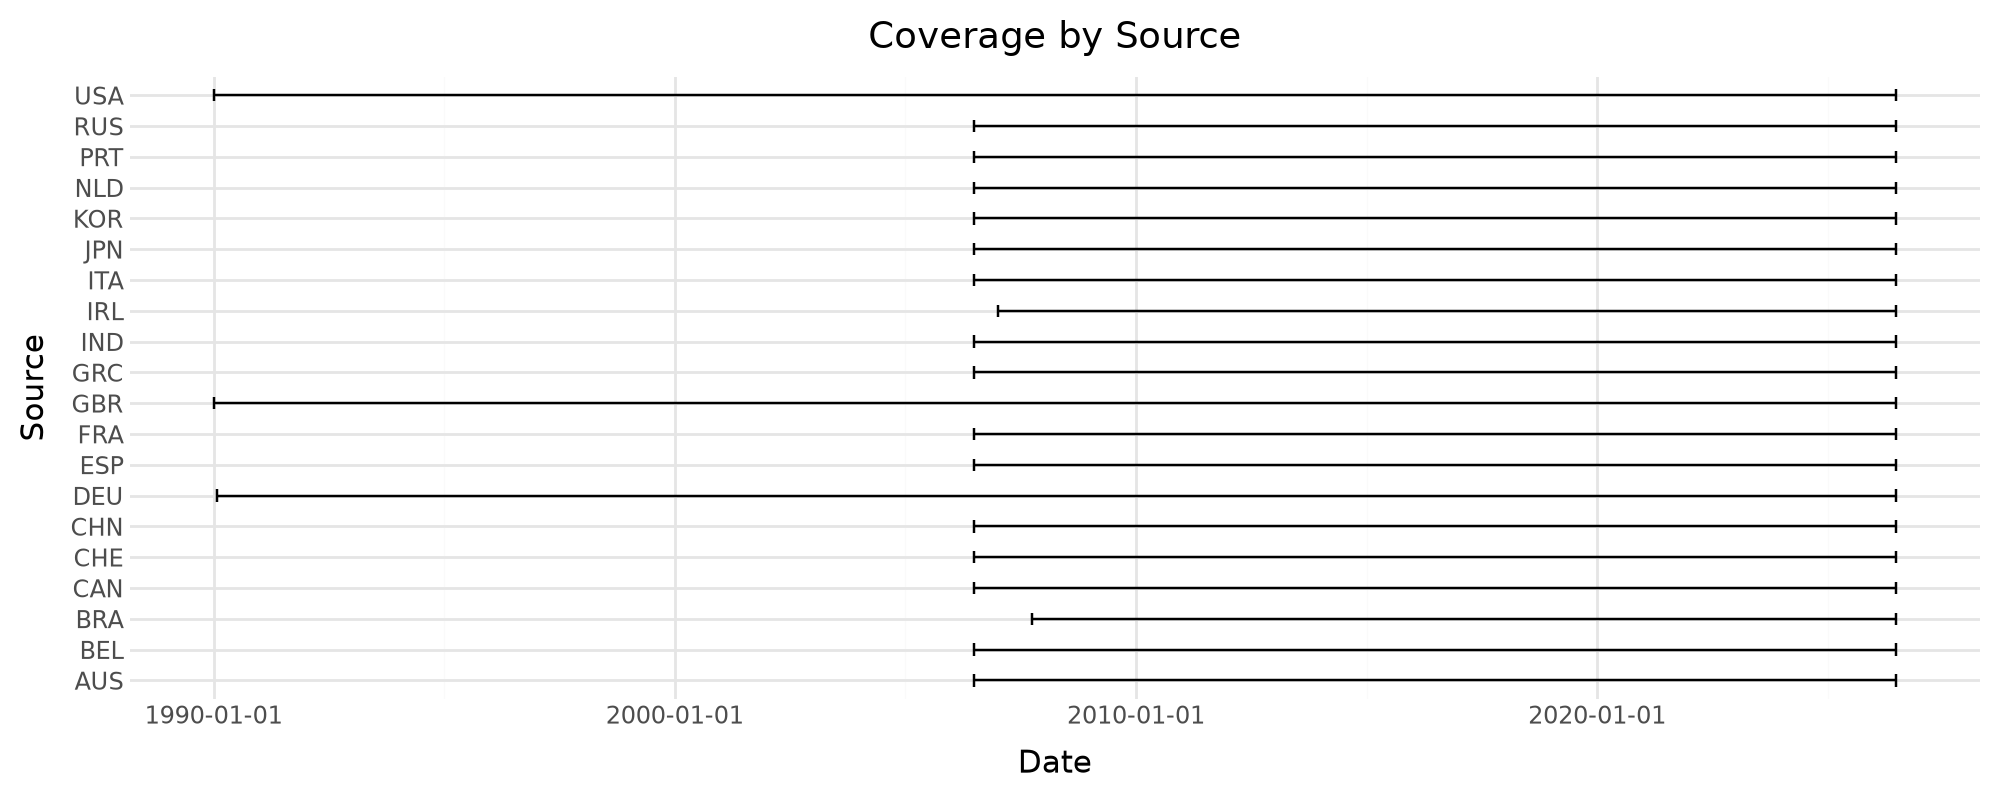

In [7]:
(
    ggplot(coverage, aes(x="min_date", y="source"))
    + geom_errorbarh(
        aes(xmin="min_date", xmax="max_date"),
        height=0.4
    )
    + labs(
        title="Coverage by Source",
        x="Date",
        y="Source"
    )
    + theme_minimal() + theme(figure_size=(10,4))
)

## Chapter B: Single-Layer Network Construction

Build intra-layer networks for each term independently, using rolling windows.

### Clean panel and unique keys


In [8]:
# Prepare data: remove nulls, sort
df_clean = df_raw.drop_nulls(subset=['date', 'source', 'term', 'rate']).sort(['date', 'source', 'term'])

print(f"After removing nulls: {df_clean.height:,} rows")

# Extract unique dates and terms for rolling window setup
dates_unique = sorted(df_clean.select('date').unique()['date'].to_list())
terms_unique = sorted(df_clean.select('term').unique()['term'].to_list())
sources_unique = sorted(df_clean.select('source').unique()['source'].to_list())

print(f"\nUnique dates: {len(dates_unique)}")
print(f"Unique terms: {len(terms_unique)}")
print(f"Unique sources: {len(sources_unique)}")

print(f"\nDate range: {dates_unique[0]} to {dates_unique[-1]}")

After removing nulls: 2,957,831 rows

Unique dates: 9775
Unique terms: 27
Unique sources: 20

Date range: 1990-01-02 to 2026-06-24


### Intra-layer network constructor


In [9]:
# Function to build a single-layer network for a specific term over a date window
def build_term_network(
    df: pl.DataFrame,
    term: str,
    date_start,
    date_end,
    measure: str = 'spearman_correlation',
    independent_threshold: float = 0.33
) -> nx.Graph:
    """
    Build a single-layer network for a specific term in a date window.
    Nodes are sources (issuers), edges are correlations of rates over time.
    """
    # Filter by term and date range
    df_term = df.filter(
        (pl.col('term') == term) &
        (pl.col('date') >= date_start) &
        (pl.col('date') <= date_end)
    )
    
    if df_term.height < 3:
        return nx.Graph()  # Empty graph if insufficient data
    
    # Pivot to wide: rows=dates, cols=sources
    df_wide = pivot_to_wide(
        df_term,
        date_column='date',
        name_column='source',
        value_column='rate'
    )
    
    nodes = [c for c in df_wide.columns if c != 'date']
    if len(nodes) < 2:
        return nx.Graph()  # Need at least 2 nodes
    
    # Compute correlation measure
    measure_df = compute_measure(
        measure,
        df_wide.select(nodes),
        nodes,
        progress=None
    )
    
    # Build network
    G = build_corr_nx(measure_df, independent_threshold=independent_threshold)
    
    return G

print("Function defined: build_term_network")

Function defined: build_term_network


### Rolling-window schedule


In [10]:
# Test on a single term with a rolling window
window_size = 125  # 125 trading days
step_size = 21    # Step by 21 days

# Use first term for testing
test_term = terms_unique[0]
print(f"Testing with term: {test_term}")

# Create rolling windows
windows = []
for i in range(0, len(dates_unique) - window_size + 1, step_size):
    date_start = dates_unique[i]
    date_end = dates_unique[i + window_size - 1]
    windows.append((date_start, date_end))

print(f"\nNumber of windows: {len(windows)}")
print(f"First window: {windows[0][0]} to {windows[0][1]}")
print(f"Last window: {windows[-1][0]} to {windows[-1][1]}")

Testing with term: Y000p5

Number of windows: 460
First window: 1990-01-02 to 1990-06-26
Last window: 2025-12-23 to 2026-06-09


### Build networks for every term and window


In [11]:
# Compute intra-layer networks for each term and window
layer_networks = {}  # {term: [G0, G1, ..., Gt]}
layer_metadata = {}  # {term: [(date_start, date_end, |V|, |E|), ...]}

for term in tqdm(terms_unique, desc='Terms'):
    networks = []
    metadata = []
    
    for date_start, date_end in tqdm(windows, desc=f'  {term}', leave=False):
        G = build_term_network(
            df_clean,
            term,
            date_start,
            date_end,
            measure='spearman_correlation',
            independent_threshold=0.33
        )
        networks.append(G)
        metadata.append({
            'term': term,
            'date_start': date_start,
            'date_end': date_end,
            'n_nodes': G.number_of_nodes(),
            'n_edges': G.number_of_edges()
        })
    
    layer_networks[term] = networks
    layer_metadata[term] = metadata

print(f"\nComputed intra-layer networks for {len(layer_networks)} terms")

Terms: 100%|██████████| 27/27 [11:39<00:00, 25.91s/it]


Computed intra-layer networks for 27 terms


### Per-term size and density summary


In [12]:
# Summarize layer statistics
print("Layer Statistics (per term):")
print("Term\t\tAvg Nodes\tAvg Edges\tDensity Range")
for term in terms_unique:
    if term in layer_metadata:
        metadata = layer_metadata[term]
        n_nodes_avg = np.mean([m['n_nodes'] for m in metadata])
        n_edges_avg = np.mean([m['n_edges'] for m in metadata])
        densities = []
        for m in metadata:
            if m['n_nodes'] > 1:
                d = m['n_edges'] / (m['n_nodes'] * (m['n_nodes'] - 1) / 2)
                densities.append(d)
        dens_range = f"[{np.min(densities):.3f}, {np.max(densities):.3f}]"
        print(f"{term}\t\t{n_nodes_avg:.1f}\t\t{n_edges_avg:.1f}\t\t{dens_range}")

Layer Statistics (per term):
Term		Avg Nodes	Avg Edges	Density Range
Y000p5		12.6		51.0		[0.000, 1.000]
Y001p0		12.6		52.9		[0.000, 1.000]
Y001p5		12.6		55.6		[0.000, 1.000]
Y002p0		12.6		58.0		[0.000, 1.000]
Y002p5		12.6		60.3		[0.000, 1.000]
Y003p0		12.6		62.5		[0.000, 1.000]
Y003p5		12.6		64.5		[0.000, 1.000]
Y004p0		12.6		66.4		[0.000, 1.000]
Y004p5		12.6		67.7		[0.000, 1.000]
Y005p0		12.6		68.7		[0.000, 1.000]
Y006p0		12.6		69.8		[0.000, 1.000]
Y007p0		12.6		70.4		[0.000, 1.000]
Y008p0		12.6		70.7		[0.000, 1.000]
Y009p0		12.6		70.7		[0.000, 1.000]
Y010p0		12.6		70.5		[0.000, 1.000]
Y011p0		12.1		66.2		[0.000, 1.000]
Y012p0		12.1		65.9		[0.000, 1.000]
Y013p0		12.1		65.6		[0.000, 1.000]
Y014p0		12.1		65.3		[0.000, 1.000]
Y015p0		12.1		64.8		[0.000, 1.000]
Y016p0		12.1		64.5		[0.000, 1.000]
Y017p0		12.1		64.1		[0.000, 1.000]
Y018p0		12.1		63.9		[0.000, 1.000]
Y019p0		12.1		63.6		[0.000, 1.000]
Y020p0		12.1		63.2		[0.000, 1.000]
Y025p0		11.9		60.1		[0.261, 1.000]
Y030p0		11.9		58.7		[

## Chapter C: Multi-Layer Network Structure

Create inter-layer edges connecting the same source across different terms, forming a yield curve network.

### Multiplex constructor (intra- + inter-layer)


In [13]:
# Create a multi-layer network structure (multiplex graph)
# Node ID format: (source, term)
# Intra-layer edges: source correlations within a term
# Inter-layer edges: same source across terms (with weight 1.0, fully connected)

def build_multilayer_network(
    layer_graphs: dict,  # {term: G_t} where G_t is a NetworkX graph
    terms_list: list,
    inter_layer_weight: float = 1.0
) -> nx.Graph:
    """
    Build a multi-layer network from single-layer graphs.
    Nodes: (source, term) tuples
    Edges: intra-layer (correlation) + inter-layer (yield curve curve connectivity)
    """
    M = nx.Graph()
    
    # Add intra-layer edges (from each layer's network)
    for term in terms_list:
        if term not in layer_graphs:
            continue
        G_term = layer_graphs[term]
        for u, v, data in G_term.edges(data=True):
            # Node IDs: (source, term)
            node_u = (u, term)
            node_v = (v, term)
            weight = 1.0 - data.get('weight', 0.5)  # Convert distance to similarity
            M.add_edge(node_u, node_v, weight=weight, layer='intra', term=term)
    
    # Add inter-layer edges (same source across terms)
    # Collect all sources
    sources = set()
    for term in terms_list:
        if term in layer_graphs:
            sources.update(layer_graphs[term].nodes())
    
    # Connect each source across consecutive terms
    for source in sources:
        for i in range(len(terms_list) - 1):
            term1, term2 = terms_list[i], terms_list[i + 1]
            node1 = (source, term1)
            node2 = (source, term2)
            # Add inter-layer edge
            M.add_edge(node1, node2, weight=inter_layer_weight, layer='inter', source=source)
    
    return M

print("Function defined: build_multilayer_network")

Function defined: build_multilayer_network


### Assemble multiplex graphs for each window


In [14]:
# Build multi-layer networks for the first time window
multilayer_networks = []
window_indices = []

for t_idx, (date_start, date_end) in enumerate(tqdm(windows, desc='Building multi-layer networks')):
    # Collect single-layer graphs for this time window
    layer_graphs_t = {}
    for term in terms_unique:
        if t_idx < len(layer_networks[term]):
            layer_graphs_t[term] = layer_networks[term][t_idx]
    
    # Build multi-layer network
    M_t = build_multilayer_network(
        layer_graphs_t,
        terms_unique,
        inter_layer_weight=1.0
    )
    
    multilayer_networks.append(M_t)
    window_indices.append((date_start, date_end))

print(f"\nBuilt {len(multilayer_networks)} multi-layer networks")

Building multi-layer networks: 100%|██████████| 460/460 [00:02<00:00, 172.68it/s]


Built 460 multi-layer networks


### Snapshot statistics (first windows)


In [15]:
# Analyze multi-layer network structure
print("Multi-Layer Network Statistics\n")
print("Window Index\tDate Start\tDate End\t\tNodes\tEdges\tLayers")
print("-" * 80)
for t_idx, (M, (date_start, date_end)) in enumerate(zip(multilayer_networks, window_indices)):
    n_nodes = M.number_of_nodes()
    n_edges = M.number_of_edges()
    
    # Count layers (unique terms present)
    terms_present = set()
    for node in M.nodes():
        if isinstance(node, tuple):
            terms_present.add(node[1])
    n_layers = len(terms_present)
    
    print(f"{t_idx}\t\t{date_start}\t{date_end}\t{n_nodes}\t{n_edges}\t{n_layers}")
    
    if t_idx > 5:
        print("...")
        break

Multi-Layer Network Statistics

Window Index	Date Start	Date End		Nodes	Edges	Layers
--------------------------------------------------------------------------------
0		1990-01-02	1990-06-26	81	112	27
1		1990-01-31	1990-07-24	81	112	27
2		1990-03-01	1990-08-22	81	106	27
3		1990-03-30	1990-09-20	81	144	27
4		1990-04-30	1990-10-18	81	144	27
5		1990-05-30	1990-11-16	81	128	27
6		1990-06-28	1990-12-17	81	129	27
...


## Chapter D: Multi-Layer Network Metrics

Compute centrality and community metrics accounting for multi-layer structure.

### Metric definitions


In [16]:
# Compute per-layer and multi-layer centrality metrics
def compute_multilayer_metrics(M: nx.Graph, terms_list: list) -> dict:
    """
    Compute centrality metrics for multi-layer network.
    Returns: per-layer and aggregate metrics.
    """
    metrics = {
        'total_nodes': M.number_of_nodes(),
        'total_edges': M.number_of_edges(),
        'density': nx.density(M),
        'n_components': nx.number_connected_components(M),
        'per_layer': {}
    }
    
    # Per-layer metrics
    for term in terms_list:
        # Extract subgraph for this term
        nodes_in_layer = [n for n in M.nodes() if isinstance(n, tuple) and n[1] == term]
        if len(nodes_in_layer) > 0:
            G_layer = M.subgraph(nodes_in_layer)
            metrics['per_layer'][term] = {
                'n_nodes': len(nodes_in_layer),
                'n_edges': G_layer.number_of_edges(),
                'density': nx.density(G_layer) if len(nodes_in_layer) > 1 else 0,
                'n_components': nx.number_connected_components(G_layer)
            }
    
    return metrics

print("Function defined: compute_multilayer_metrics")

Function defined: compute_multilayer_metrics


### Compute metrics across windows


In [17]:
# Compute metrics for all multi-layer networks
multilayer_metrics_list = []

for t_idx, M in enumerate(tqdm(multilayer_networks, desc='Computing metrics')):
    metrics = compute_multilayer_metrics(M, terms_unique)
    metrics['window_idx'] = t_idx
    metrics['date_start'] = window_indices[t_idx][0]
    metrics['date_end'] = window_indices[t_idx][1]
    multilayer_metrics_list.append(metrics)

print(f"Computed metrics for {len(multilayer_metrics_list)} windows")

# Convert to DataFrame for analysis
metrics_data = []
for m in multilayer_metrics_list:
    metrics_data.append({
        'window_idx': m['window_idx'],
        'date_start': m['date_start'],
        'date_end': m['date_end'],
        'total_nodes': m['total_nodes'],
        'total_edges': m['total_edges'],
        'density': m['density'],
        'n_components': m['n_components']
    })

metrics_df = pl.DataFrame(metrics_data)
print("\nMulti-layer network metrics:")
print(metrics_df.head(10))

Computing metrics: 100%|██████████| 460/460 [00:05<00:00, 81.77it/s] 

Computed metrics for 460 windows

Multi-layer network metrics:
shape: (10, 7)
┌────────────┬────────────┬────────────┬─────────────┬─────────────┬──────────┬──────────────┐
│ window_idx ┆ date_start ┆ date_end   ┆ total_nodes ┆ total_edges ┆ density  ┆ n_components │
│ ---        ┆ ---        ┆ ---        ┆ ---         ┆ ---         ┆ ---      ┆ ---          │
│ i64        ┆ str        ┆ str        ┆ i64         ┆ i64         ┆ f64      ┆ i64          │
╞════════════╪════════════╪════════════╪═════════════╪═════════════╪══════════╪══════════════╡
│ 0          ┆ 1990-01-02 ┆ 1990-06-26 ┆ 81          ┆ 112         ┆ 0.034568 ┆ 1            │
│ 1          ┆ 1990-01-31 ┆ 1990-07-24 ┆ 81          ┆ 112         ┆ 0.034568 ┆ 1            │
│ 2          ┆ 1990-03-01 ┆ 1990-08-22 ┆ 81          ┆ 106         ┆ 0.032716 ┆ 1            │
│ 3          ┆ 1990-03-30 ┆ 1990-09-20 ┆ 81          ┆ 144         ┆ 0.044444 ┆ 1            │
│ 4          ┆ 1990-04-30 ┆ 1990-10-18 ┆ 81          ┆ 144         

### Inspect the metrics table


In [20]:
metrics_df.sample(5).sort(['date_start'])
# metrics_df.filter(pl.col("n_components")>1).sample(10).sort(['date_start'])

window_idx,date_start,date_end,total_nodes,total_edges,density,n_components
i64,str,str,i64,i64,f64,i64
25,"""1992-01-08""","""1992-06-30""",81,100,0.030864,1
112,"""1999-01-27""","""1999-07-21""",81,153,0.047222,1
170,"""2003-09-30""","""2004-03-22""",81,156,0.048148,1
319,"""2015-03-02""","""2015-08-21""",540,3376,0.023198,1
415,"""2022-09-14""","""2023-03-01""",540,3644,0.02504,1


## Chapter E: Temporal Analysis of Multi-Layer Evolution

Analyze how the multi-layer network structure changes over time.

### Aggregate evolution (plotnine)


In [21]:
# Visualize multi-layer network evolution (plotnine)
from plotnine import (
    ggplot,
    aes,
    geom_line,
    facet_wrap,
    labs,
    theme,
    theme_bw,
    scale_color_manual,
    guides,
    element_text,
    element_blank,
)

METRIC_SPECS = {
    "total_nodes": ("Network Size Growth", "#0284c7"),
    "total_edges": ("Edge Count Evolution", "#7c3aed"),
    "density": ("Connectivity Density", "#059669"),
    "n_components": ("Network Fragmentation", "#dc2626"),
}

plot_df = (
    metrics_df.select(["window_idx", *METRIC_SPECS.keys()])
    .to_pandas()
    .melt(id_vars="window_idx", var_name="metric", value_name="value")
)
plot_df["facet_title"] = plot_df["metric"].map(lambda m: METRIC_SPECS[m][0])
color_map = {m: spec[1] for m, spec in METRIC_SPECS.items()}

evolution_plot = (
    ggplot(plot_df, aes("window_idx", "value", color="metric", group="metric"))
    + geom_line(size=1.1, alpha=0.95)
    + facet_wrap("~ facet_title", ncol=2, scales="free_y")
    + scale_color_manual(values=color_map)
    + guides(color=None)
    + labs(
        title="Multi-Layer Network Evolution Over Time",
        x="Window Index",
        y="",
    )
    + theme_bw(base_size=13)
    + theme(
        figure_size=(14, 8),
        plot_title=element_text(size=16, weight="bold", ha="center"),
        strip_text=element_text(size=12, weight="bold"),
        strip_background=element_blank(),
        axis_text=element_text(size=11),
        axis_title_x=element_text(size=12, margin={"t": 10}),
        panel_grid_major=element_blank(),
        panel_grid_minor=element_blank(),
    )
)


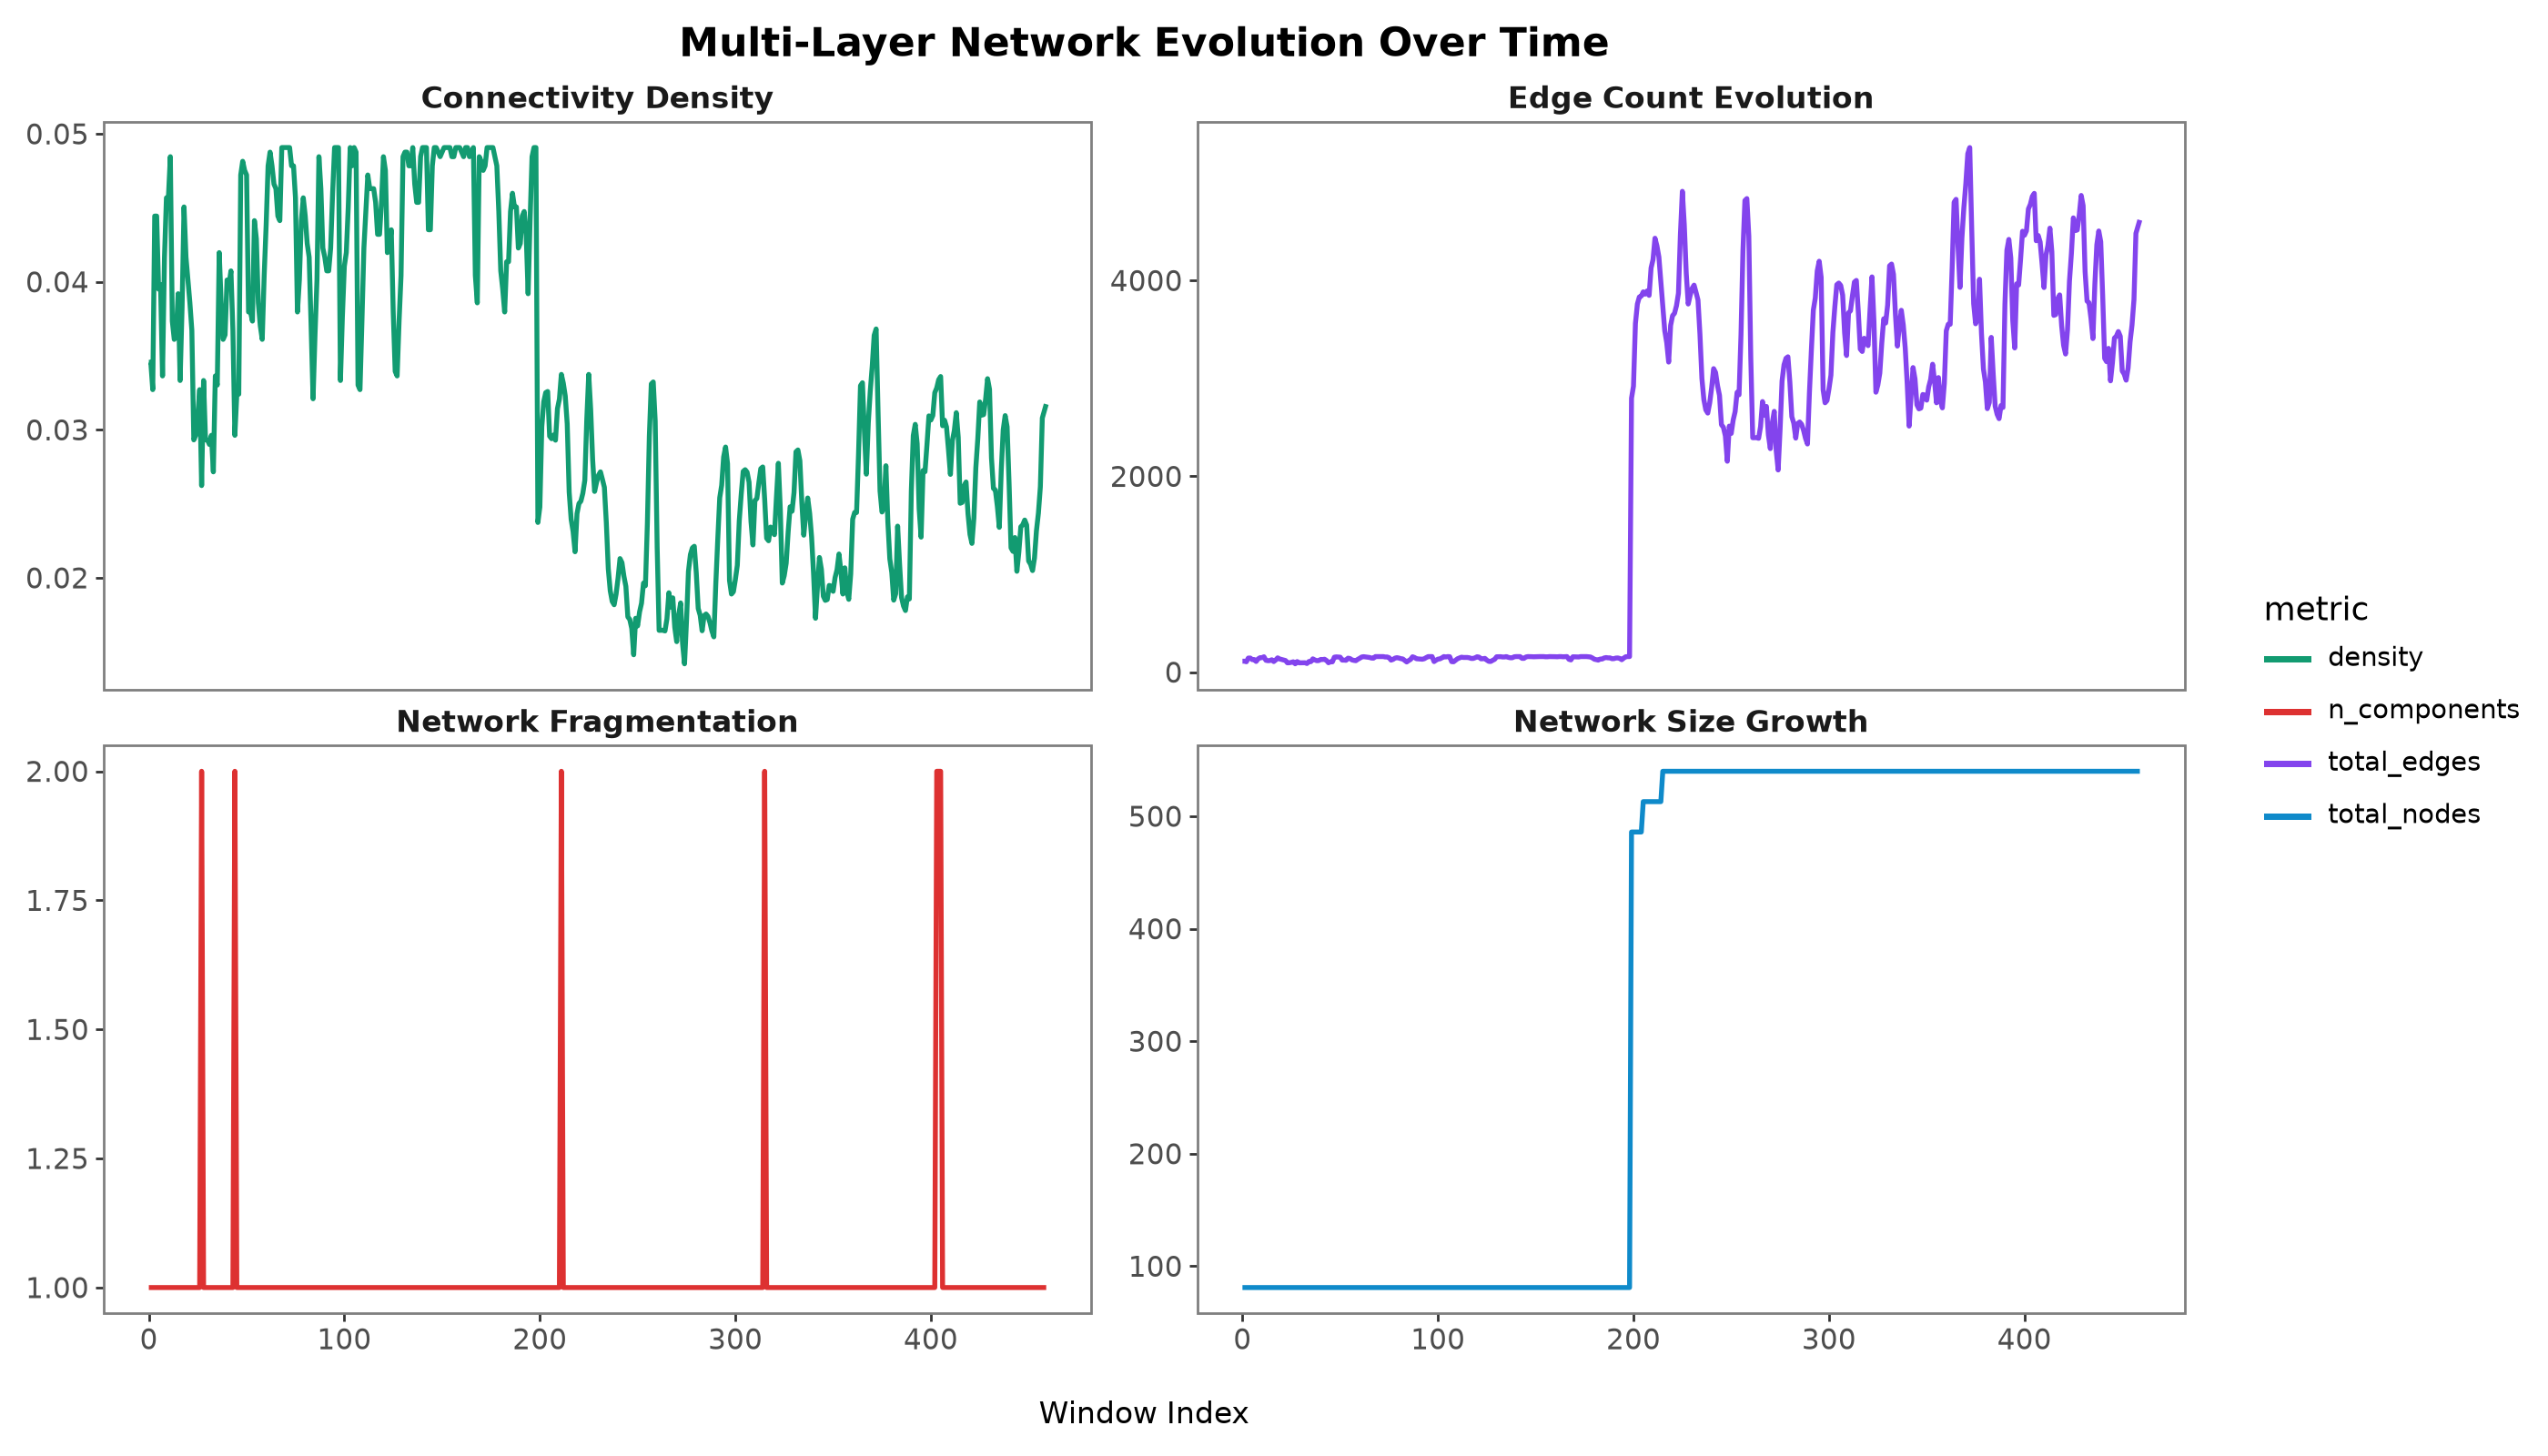

In [22]:
evolution_plot.save(
    "multilayer_evolution.png",
    dpi=150,
    width=14,
    height=8,
    verbose=False,
)
evolution_plot

### Per-layer statistics over time


In [23]:
# Per-layer statistics over time
print("Per-Layer Statistics Over Time\n")

per_layer_data = []
for m in multilayer_metrics_list:
    for term, layer_metrics in m.get('per_layer', {}).items():
        per_layer_data.append({
            'window_idx': m['window_idx'],
            'date_end': m['date_end'],
            'term': term,
            'n_nodes': layer_metrics['n_nodes'],
            'n_edges': layer_metrics['n_edges'],
            'density': layer_metrics['density'],
            'n_components': layer_metrics['n_components']
        })

per_layer_df = pl.DataFrame(per_layer_data)

print("Sample per-layer metrics (first 20 rows):")
print(per_layer_df.head(20))

print("\nAverage per-layer metrics:")
per_layer_summary = per_layer_df.group_by('term').agg([
    pl.col('n_nodes').mean().round(1).alias('avg_nodes'),
    pl.col('n_edges').mean().round(1).alias('avg_edges'),
    pl.col('density').mean().round(3).alias('avg_density'),
]).sort('term')
print(per_layer_summary)

Per-Layer Statistics Over Time

Sample per-layer metrics (first 20 rows):
shape: (20, 7)
┌────────────┬────────────┬────────┬─────────┬─────────┬──────────┬──────────────┐
│ window_idx ┆ date_end   ┆ term   ┆ n_nodes ┆ n_edges ┆ density  ┆ n_components │
│ ---        ┆ ---        ┆ ---    ┆ ---     ┆ ---     ┆ ---      ┆ ---          │
│ i64        ┆ str        ┆ str    ┆ i64     ┆ i64     ┆ f64      ┆ i64          │
╞════════════╪════════════╪════════╪═════════╪═════════╪══════════╪══════════════╡
│ 0          ┆ 1990-06-26 ┆ Y000p5 ┆ 3       ┆ 1       ┆ 0.333333 ┆ 2            │
│ 0          ┆ 1990-06-26 ┆ Y001p0 ┆ 3       ┆ 2       ┆ 0.666667 ┆ 1            │
│ 0          ┆ 1990-06-26 ┆ Y001p5 ┆ 3       ┆ 2       ┆ 0.666667 ┆ 1            │
│ 0          ┆ 1990-06-26 ┆ Y002p0 ┆ 3       ┆ 2       ┆ 0.666667 ┆ 1            │
│ 0          ┆ 1990-06-26 ┆ Y002p5 ┆ 3       ┆ 2       ┆ 0.666667 ┆ 1            │
│ …          ┆ …          ┆ …      ┆ …       ┆ …       ┆ …        ┆ …            

### Interactive network visualization (pyvis)

Drag/zoom the graph below. Intra-layer edges are color-coded by weight; inter-layer edges are purple.


In [26]:
# window_indices

In [28]:
import base64

from IPython.display import HTML, display

from tgraphportfolio.analysis.pyvis_plot import multilayer_graph_to_html

multilayer_index = -10
w0_start, w0_end = window_indices[multilayer_index]
html = multilayer_graph_to_html(
    multilayer_networks[multilayer_index],
    title=f"Multi-Layer Network (window {multilayer_index}: {w0_start} → {w0_end})",
    height="900px",
)
encoded = base64.b64encode(html.encode("utf-8")).decode("ascii")
display(
    HTML(
        "<p style='color:#cbd5e1;font-family:Segoe UI,sans-serif;margin:0 0 8px 0'>"
        "Grid: columns = issuers, rows = terms (short → long). "
        "Scroll to zoom, drag to pan, hover for node/edge details. "
        "Bottom-right buttons: zoom / fit."
        "</p>"
        f'<iframe src="data:text/html;base64,{encoded}" '
        'width="100%" height="900px" frameborder="0" '
        'style="border:1px solid #334155; background:#0f172a;"></iframe>'
    )
)


## Chapter F: Inter-Layer Connectivity Analysis

Analyze how yield curve structure (inter-layer connectivity) evolves over time.

### Count intra- vs inter-layer edges


In [ ]:
# Count inter-layer vs intra-layer edges
def count_edge_types(M: nx.Graph) -> dict:
    """
    Count edges by type (intra-layer vs inter-layer).
    """
    intra_edges = 0
    inter_edges = 0
    
    for u, v, data in M.edges(data=True):
        edge_layer = data.get('layer', 'unknown')
        if edge_layer == 'intra':
            intra_edges += 1
        elif edge_layer == 'inter':
            inter_edges += 1
    
    return {
        'intra_edges': intra_edges,
        'inter_edges': inter_edges,
        'total_edges': intra_edges + inter_edges
    }

edge_type_data = []
for t_idx, M in enumerate(multilayer_networks):
    counts = count_edge_types(M)
    counts['window_idx'] = t_idx
    counts['date_end'] = window_indices[t_idx][1]
    edge_type_data.append(counts)

edge_type_df = pl.DataFrame(edge_type_data)
edge_type_df = edge_type_df.with_columns([
    (100.0 * pl.col('intra_edges') / pl.col('total_edges')).alias('pct_intra'),
    (100.0 * pl.col('inter_edges') / pl.col('total_edges')).alias('pct_inter')
])

print("Edge Type Distribution Over Time:")
print(edge_type_df.head(15))

### Edge-type composition over time


In [ ]:
# Visualize edge type evolution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Intra-Layer vs Inter-Layer Connectivity', fontsize=14, fontweight='bold')

# Plot 1: Absolute edge counts
ax = axes[0]
ax.plot(edge_type_df['window_idx'], edge_type_df['intra_edges'], marker='o', label='Intra-layer', linewidth=2, color='#0ea5e9')
ax.plot(edge_type_df['window_idx'], edge_type_df['inter_edges'], marker='s', label='Inter-layer', linewidth=2, color='#a78bfa')
ax.set_xlabel('Window Index')
ax.set_ylabel('Edge Count')
ax.set_title('Edge Counts by Type')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_facecolor('#0f172a')

# Plot 2: Percentage stacked
ax = axes[1]
ax.fill_between(edge_type_df['window_idx'], 0, edge_type_df['pct_intra'], alpha=0.7, label='Intra-layer', color='#0ea5e9')
ax.fill_between(edge_type_df['window_idx'], edge_type_df['pct_intra'], 100, alpha=0.7, label='Inter-layer', color='#a78bfa')
ax.set_xlabel('Window Index')
ax.set_ylabel('Percentage (%)')
ax.set_title('Edge Type Composition')
ax.set_ylim([0, 100])
ax.legend(loc='center left')
ax.grid(True, alpha=0.3, axis='y')
ax.set_facecolor('#0f172a')

for ax in axes.flat:
    ax.tick_params(colors='#cbd5e1')
    ax.spines['bottom'].set_color('#475569')
    ax.spines['left'].set_color('#475569')
    ax.xaxis.label.set_color('#cbd5e1')
    ax.yaxis.label.set_color('#cbd5e1')
    ax.title.set_color('#cbd5e1')
    for spine in ax.spines.values():
        spine.set_visible(True)

plt.tight_layout()
plt.savefig('multilayer_edge_types.png', dpi=150, facecolor='#0f172a', edgecolor='none')
plt.show()

print("Edge type evolution plot saved")

## Chapter G: Community Detection in Multi-Layer Networks

Detect communities within and across layers to identify groups of correlated issuers.

### Spectral embedding + KMeans detector


In [ ]:
# Community detection on multi-layer networks
# Use modularity-based approach treating multi-layer as single network
from graspologic.embed import AdjacencySpectralEmbed
from sklearn.cluster import KMeans

def detect_multilayer_communities(M: nx.Graph, n_components: int = 2) -> dict:
    """
    Detect communities using spectral embedding + KMeans on multi-layer network.
    """
    if M.number_of_nodes() < 3:
        return {'communities': {}, 'n_clusters': 0}
    
    # Convert to adjacency matrix
    A = nx.to_numpy_array(M, nodelist=sorted(M.nodes()))
    node_list = sorted(M.nodes())
    
    try:
        # Spectral embedding
        ase = AdjacencySpectralEmbed(
            n_components=min(n_components, len(node_list) - 1),
            check_lcc=False,
        )
        X = ase.fit_transform(A)
        if isinstance(X, tuple):
            X = np.hstack(X)
        
        # KMeans clustering
        kmeans = KMeans(n_clusters=min(3, len(node_list)), random_state=0, n_init=10)
        labels = kmeans.fit_predict(X)
        
        communities = {node: int(label) for node, label in zip(node_list, labels)}
        
        return {
            'communities': communities,
            'n_clusters': len(set(labels)),
            'inertia': float(kmeans.inertia_)
        }
    except Exception as e:
        return {'communities': {}, 'n_clusters': 0, 'error': str(e)}

print("Function defined: detect_multilayer_communities")

### Number of multiplex windows


In [ ]:
len(multilayer_networks)

### Communities on the first windows


In [ ]:
# Detect communities for first few time windows
multilayer_communities = []

for t_idx, M in enumerate(tqdm(multilayer_networks, desc='Detecting communities')):
    result = detect_multilayer_communities(M, n_components=3)
    result['window_idx'] = t_idx
    result['date_end'] = window_indices[t_idx][1]
    multilayer_communities.append(result)

print(f"\nCommunity detection results:")
for i, result in enumerate(multilayer_communities[:5]):
    print(f"Window {i}: {result['n_clusters']} communities, inertia={result.get('inertia', 'N/A')}")

# Part II: Factor Models, Residuals, and Stress

Chapters H–O continue from the panel already loaded in Part I (enhanced notebook reload/coverage cells are omitted as duplicates).


## Chapter H: Yield Curve Factor Extraction (Nelson-Siegel & PCA)

Extract interpretable factors (level, slope, curvature) that drive yield curve dynamics.

### Market-wide Nelson-Siegel factors


In [ ]:
# Fit Nelson-Siegel model to average curve across all issuers (market-wide curve)
# This gives us "common factors" shared across market

# Group by date, average across all sources
df_market = df_clean.group_by('date').agg([
    pl.col('rate').mean().alias('rate')
]).sort('date')

# Pivot: dates ├ù terms
df_market_wide = pivot_to_wide(
    df_clean.group_by(['date', 'term']).agg(pl.col('rate').mean().alias('rate')),
    date_column='date',
    name_column='term',
    value_column='rate'
)

term_cols = [c for c in df_market_wide.columns if c != 'date']
print(f"Market-wide yield matrix: {df_market_wide.height} dates ├ù {len(term_cols)} terms")

# Fit Nelson-Siegel for market-wide curve
ns_market = fit_nelson_siegel_batch(
    df_market_wide,
    date_col='date',
    maturities=term_cols,
    decay=1.0  # Fixed lambda for stability
)

print("\nNelson-Siegel factors (market average):")
print(ns_market.head(10))

### PCA modes of the yield matrix


In [ ]:
# PCA on yield matrix to identify common modes
yields_matrix = df_market_wide.select(term_cols).to_numpy()
yields_matrix = yields_matrix[~np.isnan(yields_matrix).any(axis=1)]  # Remove rows with NaN

pca_result = fit_pca(yields_matrix, n_components=3)

print("PCA Explained Variance:")
for i, var in enumerate(pca_result.variance_explained):
    print(f"  PC{i+1}: {var*100:.2f}%")
print(f"  Cumulative: {np.sum(pca_result.variance_explained)*100:.2f}%")

print("\nPC Loadings (maturity structure):")
loadings_df = pl.DataFrame({
    'term': term_cols,
    'PC1_loading': pca_result.loadings[:, 0],
    'PC2_loading': pca_result.loadings[:, 1],
    'PC3_loading': pca_result.loadings[:, 2],
})
print(loadings_df)

## Chapter I: Residual-Based Networks

Build networks from Nelson-Siegel residuals (yields minus fitted curve) to isolate issuer-specific credit behavior.

### Extract Nelson-Siegel residuals by issuer


In [ ]:
# Extract NS residuals for all sources
residuals_by_source = {}
residuals_metadata = {}

for source in tqdm(sources_unique[:5], desc='Extracting NS residuals'):
    df_source = df_clean.filter(pl.col('source') == source)
    
    # Pivot: dates ├ù terms
    df_source_wide = pivot_to_wide(
        df_source,
        date_column='date',
        name_column='term',
        value_column='rate'
    )
    
    try:
        residuals_matrix, metadata = extract_ns_residuals(
            df_source_wide,
            date_col='date',
            term_cols=term_cols,
            decay=1.0
        )
        
        residuals_by_source[source] = residuals_matrix
        residuals_metadata[source] = metadata
    except Exception as e:
        print(f"Error processing {source}: {str(e)}")
        continue

print(f"Extracted residuals for {len(residuals_by_source)} sources")

### Residual correlation networks by maturity


In [ ]:
# Build residual-based networks: correlations between issuers at each maturity
def build_residual_network(
    residuals_dict: dict,  # {source: residuals_matrix}
    term_idx: int,  # which maturity term
    threshold: float = 0.4
) -> nx.Graph:
    """Build network from residual correlations at given term."""
    sources = list(residuals_dict.keys())
    
    # Extract residual time series at this term for each source
    residuals_ts = np.array([residuals_dict[s][:, term_idx] for s in sources])
    residuals_ts = residuals_ts[:, ~np.isnan(residuals_ts).any(axis=0)]  # Remove NaN columns
    
    # Compute correlations
    corr_matrix = np.corrcoef(residuals_ts)
    
    # Build network
    G = nx.Graph()
    for i, s1 in enumerate(sources):
        G.add_node(s1)
        for j, s2 in enumerate(sources):
            if i < j and abs(corr_matrix[i, j]) > threshold:
                G.add_edge(s1, s2, weight=corr_matrix[i, j])
    
    return G, corr_matrix

# Build residual networks for first 3 maturities
residual_networks = {}
residual_correlations = {}

for term_idx, term in enumerate(term_cols[:3]):
    G, corr = build_residual_network(residuals_by_source, term_idx, threshold=0.3)
    residual_networks[term] = G
    residual_correlations[term] = corr
    print(f"{term}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

## Chapter J: Temporal Dynamics & Factor Evolution

Track how yield curve factors evolve over time; identify regime changes.

### Factor trajectories


In [ ]:
# Compute factor trajectories over time
factor_stats = compute_factor_trajectories(ns_market, window_size=30, step_size=10)

# Convert to DataFrame for visualization
factor_evolution = pl.DataFrame({
    'window_idx': np.arange(len(factor_stats['windows'])),
    'date_end': [w[1] for w in factor_stats['windows']],
    'level_mean': factor_stats['level_mean'],
    'level_std': factor_stats['level_std'],
    'slope_mean': factor_stats['slope_mean'],
    'slope_std': factor_stats['slope_std'],
    'curvature_mean': factor_stats['curvature_mean'],
    'curvature_std': factor_stats['curvature_std'],
})

print("Factor evolution over time:")
print(factor_evolution.head(10))

### Regime classification (Gaussian mixture)


In [ ]:
# Regime classification via Gaussian Mixture Model
factors_array = ns_market.select(['level', 'slope', 'curvature']).to_numpy()
regimes = classify_yield_curve_regimes(factors_array, n_regimes=3)

# Add regime to NS dataframe
ns_market_with_regimes = ns_market.with_columns(
    regime=pl.Series(regimes.regime_labels)
)

print(f"Identified {len(np.unique(regimes.regime_labels))} yield curve regimes:")
for i, name in enumerate(regimes.regime_names):
    count = np.sum(regimes.regime_labels == i)
    print(f"  {name}: {count} observations")
    print(f"    Mean factors: {regimes.regime_means[i]}")

### Factor evolution plots


In [ ]:
# Visualize factor evolution and regime transitions
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
fig.suptitle('Yield Curve Factor Evolution Over Time', fontsize=14, fontweight='bold')

for ax_idx, (factor_name, factor_col, regime_colors) in enumerate([
    ('Level', 'level', ['#0ea5e9', '#a78bfa', '#34d399']),
    ('Slope', 'slope', ['#f87171', '#a78bfa', '#fbbf24']),
    ('Curvature', 'curvature', ['#ec4899', '#8b5cf6', '#14b8a6'])
]):
    ax = axes[ax_idx]
    
    # Plot factor value
    ax.plot(factor_evolution['window_idx'], factor_evolution[f'{factor_col}_mean'],
            marker='o', linewidth=2, markersize=5, color=regime_colors[0], label=f'{factor_name} (mean)')
    
    # Shade regime background
    for i, window_idx in enumerate(factor_evolution['window_idx']):
        regime_color = regime_colors[regimes.regime_labels[min(i, len(regimes.regime_labels)-1)]]
        ax.axvspan(window_idx-0.5, window_idx+0.5, alpha=0.1, color=regime_color)
    
    ax.set_ylabel(factor_name, color='#cbd5e1')
    ax.set_facecolor('#0f172a')
    ax.grid(True, alpha=0.3)
    ax.tick_params(colors='#cbd5e1')
    for spine in ax.spines.values():
        spine.set_color('#475569')

axes[-1].set_xlabel('Window Index', color='#cbd5e1')
plt.tight_layout()
plt.savefig('factor_evolution.png', dpi=150, facecolor='#0f172a')
plt.show()

print("Factor evolution plot saved")

## Chapter K: Stress Testing & Correlation Breakdown

Detect market stress through correlation matrix changes and liquidity indicators.

### Rolling correlation stability


In [ ]:
# Compute rolling correlation matrices across windows; detect breakdowns
def compute_correlation_stability(
    residuals_dict: dict,
    window_size: int = 30,
    step_size: int = 10
) -> dict:
    """Detect correlation stability over rolling windows."""
    
    # Stack residuals: (n_sources, n_dates, n_terms)
    sources = list(residuals_dict.keys())
    dates_ref = residuals_dict[sources[0]].shape[0]
    terms_ref = residuals_dict[sources[0]].shape[1]
    
    stability_metrics = {
        'windows': [],
        'avg_abs_correlation': [],
        'correlation_variance': [],
        'n_significant_edges': []  # edges with |r| > 0.5
    }
    
    for w_start in range(0, dates_ref - window_size + 1, step_size):
        w_end = w_start + window_size
        
        # Extract window data
        window_residuals = np.array([
            residuals_dict[s][w_start:w_end, :]
            for s in sources
        ])  # (n_sources, window_size, n_terms)
        
        # Compute correlations at middle term
        term_idx = terms_ref // 2
        ts = window_residuals[:, :, term_idx]  # (n_sources, window_size)
        ts = ts[:, ~np.isnan(ts).any(axis=0)]
        
        if ts.shape[1] > 1:
            corr_matrix = np.corrcoef(ts)
            abs_corr = np.abs(corr_matrix[np.triu_indices_from(corr_matrix, k=1)])
            
            stability_metrics['windows'].append((w_start, w_end))
            stability_metrics['avg_abs_correlation'].append(float(np.mean(abs_corr)))
            stability_metrics['correlation_variance'].append(float(np.var(abs_corr)))
            stability_metrics['n_significant_edges'].append(int(np.sum(abs_corr > 0.5)))
    
    return stability_metrics

# Compute stress metrics
stress_metrics = compute_correlation_stability(residuals_by_source, window_size=30, step_size=10)

stress_df = pl.DataFrame({
    'window_idx': np.arange(len(stress_metrics['windows'])),
    'avg_abs_corr': stress_metrics['avg_abs_correlation'],
    'corr_variance': stress_metrics['correlation_variance'],
    'n_sig_edges': stress_metrics['n_significant_edges'],
})

print("Correlation stability metrics:")
print(stress_df.head(15))

### Stress-indicator plots


In [ ]:
# Visualize stress indicators
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Market Stress Detection Metrics', fontsize=14, fontweight='bold')

# Average absolute correlation (high = correlated; low = breakdown)
ax = axes[0, 0]
ax.plot(stress_df['window_idx'], stress_df['avg_abs_corr'], marker='o', linewidth=2, color='#0ea5e9')
ax.axhline(np.mean(stress_df['avg_abs_corr']), color='#a78bfa', linestyle='--', label='Mean')
ax.set_title('Average Absolute Correlation')
ax.set_ylabel('Correlation', color='#cbd5e1')
ax.set_facecolor('#0f172a')
ax.grid(True, alpha=0.3)
ax.tick_params(colors='#cbd5e1')
ax.legend()

# Correlation variance (high = heterogeneous linkages)
ax = axes[0, 1]
ax.plot(stress_df['window_idx'], stress_df['corr_variance'], marker='s', linewidth=2, color='#34d399')
ax.set_title('Correlation Variance (Heterogeneity)')
ax.set_ylabel('Variance', color='#cbd5e1')
ax.set_facecolor('#0f172a')
ax.grid(True, alpha=0.3)
ax.tick_params(colors='#cbd5e1')

# Number of significant edges
ax = axes[1, 0]
ax.bar(stress_df['window_idx'], stress_df['n_sig_edges'], color='#f87171', alpha=0.7)
ax.set_title('Strongly Correlated Pairs (|r| > 0.5)')
ax.set_ylabel('Count', color='#cbd5e1')
ax.set_xlabel('Window Index', color='#cbd5e1')
ax.set_facecolor('#0f172a')
ax.tick_params(colors='#cbd5e1')
ax.grid(True, alpha=0.3, axis='y')

# Stress indicator (inverse of stability)
ax = axes[1, 1]
stress_indicator = (1.0 - stress_df['avg_abs_corr'] / stress_df['avg_abs_corr'].max()) * 100
colors = ['#ec4899' if s > 50 else '#0ea5e9' for s in stress_indicator]
ax.bar(stress_df['window_idx'], stress_indicator, color=colors, alpha=0.7)
ax.set_title('Stress Indicator (0=calm, 100=stressed)')
ax.set_ylabel('Stress %', color='#cbd5e1')
ax.set_xlabel('Window Index', color='#cbd5e1')
ax.set_facecolor('#0f172a')
ax.tick_params(colors='#cbd5e1')
ax.grid(True, alpha=0.3, axis='y')

for ax in axes.flat:
    for spine in ax.spines.values():
        spine.set_color('#475569')

plt.tight_layout()
plt.savefig('stress_detection.png', dpi=150, facecolor='#0f172a')
plt.show()

print("Stress detection plot saved")

## Chapter L: Advanced Centrality & Network Influence

Compute centrality accounting for multi-layer structure and spreading dynamics.

### Multi-layer degree centrality (residual graphs)


In [ ]:
# Compute multi-layer centrality by summing across layers
def compute_multilayer_centrality(
    layer_graphs: dict  # {term: G}
) -> dict:
    """Compute centrality accounting for all layers."""
    
    # Collect all nodes
    all_nodes = set()
    for G in layer_graphs.values():
        all_nodes.update(G.nodes())
    
    centrality = {node: 0.0 for node in all_nodes}
    
    # Sum degree across layers
    for term, G in layer_graphs.items():
        layer_centrality = dict(G.degree())
        for node, degree in layer_centrality.items():
            centrality[node] += degree
    
    # Normalize by number of layers
    n_layers = len(layer_graphs)
    for node in centrality:
        centrality[node] /= n_layers
    
    return centrality

# Compute for residual networks
multilayer_centrality = compute_multilayer_centrality(residual_networks)

# Sort by centrality
sorted_nodes = sorted(multilayer_centrality.items(), key=lambda x: x[1], reverse=True)

print("Top 10 most central issuers (multi-layer degree centrality):")
for i, (node, centrality) in enumerate(sorted_nodes[:10], 1):
    print(f"  {i}. {node}: {centrality:.2f}")

## Chapter M: 3D Interactive Visualization

Visualize multi-layer network in 3D space (issuer ├ù term ├ù time).

### Interactive network visualization (pyvis)

Drag/zoom the graph below. Intra-layer edges are color-coded by |correlation|; inter-layer edges are purple.


In [ ]:
def build_multilayer_from_layer_graphs(
    layer_graphs: dict,
    inter_layer_weight: float = 1.0,
) -> nx.Graph:
    """Combine per-term NetworkX graphs into one multi-layer network."""
    M = nx.Graph()
    terms_list = list(layer_graphs.keys())

    for term, G_term in layer_graphs.items():
        for u, v, data in G_term.edges(data=True):
            weight = abs(float(data.get("weight", 0.5)))
            M.add_edge((u, term), (v, term), weight=weight, layer="intra", term=term)

    sources: set = set()
    for G in layer_graphs.values():
        sources.update(G.nodes())

    for source in sources:
        for i in range(len(terms_list) - 1):
            term1, term2 = terms_list[i], terms_list[i + 1]
            M.add_edge(
                (source, term1),
                (source, term2),
                weight=inter_layer_weight,
                layer="inter",
                source=source,
            )

    return M

import base64

from IPython.display import HTML, display

from tgraphportfolio.analysis.pyvis_plot import multilayer_graph_to_html

residual_multilayer = build_multilayer_from_layer_graphs(residual_networks)
html = multilayer_graph_to_html(
    residual_multilayer,
    title="Residual-Based Multi-Layer Network (NS factors removed)",
    height="900px",
)
encoded = base64.b64encode(html.encode("utf-8")).decode("ascii")
display(
    HTML(
        "<p style='color:#cbd5e1;font-family:Segoe UI,sans-serif;margin:0 0 8px 0'>"
        "Grid: columns = issuers, rows = terms (short → long). "
        "Scroll to zoom, drag to pan, hover for node/edge details. "
        "Bottom-right buttons: zoom / fit."
        "</p>"
        f'<iframe src="data:text/html;base64,{encoded}" '
        'width="100%" height="900px" frameborder="0" '
        'style="border:1px solid #334155; background:#0f172a;"></iframe>'
    )
)


### 3D issuer × term × centrality scatter


In [ ]:
# Create 3D scatter plot: issuer ├ù term ├ù centrality
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')

# Assign coordinates
sources_list = list(multilayer_centrality.keys())
terms_list = list(residual_networks.keys())

for s_idx, source in enumerate(sources_list):
    for t_idx, term in enumerate(terms_list):
        G = residual_networks[term]
        degree = G.degree(source, default=0)
        
        # Position: (source_index, term_index, degree)
        color = plt.cm.viridis(degree / 10.0)  # Color by degree
        ax.scatter(s_idx, t_idx, degree, c=[color], s=100, alpha=0.7)

ax.set_xlabel('Issuer Index', color='#cbd5e1')
ax.set_ylabel('Term Index', color='#cbd5e1')
ax.set_zlabel('Degree Centrality', color='#cbd5e1')
ax.set_title('3D Multi-Layer Network: Issuer ├ù Term ├ù Centrality', fontsize=12, color='#e2e8f0')
ax.set_facecolor('#0f172a')
ax.grid(True, alpha=0.3)

plt.savefig('multilayer_3d_network.png', dpi=150, facecolor='#0f172a', bbox_inches='tight')
plt.show()

print("3D network visualization saved")

## Chapter N: Signal Subgraph Detection

Identify edges and nodes most predictive of regime transitions.

### Regime-discriminating signal edges


In [ ]:
# Compute edge importance for regime prediction
# Edges that change most between normal/stress regimes are "signal edges"

def compute_signal_edges(
    residual_correlations: dict,  # {term: corr_matrix}
    regime_labels: np.ndarray,  # (n_dates,) regime assignments
    sources: list[str],
    n_top: int = 10
) -> list:
    """Identify edges that best discriminate between regimes."""
    
    edge_discrimination = {}
    
    for term, corr_matrix in residual_correlations.items():
        # Separate correlation matrices by regime
        regime_corrs = {}
        for regime_id in np.unique(regime_labels):
            mask = regime_labels == regime_id
            regime_corrs[regime_id] = corr_matrix[mask].mean(axis=0)  # Average over rows in regime
        
        # Edge discrimination = difference between regimes
        regimes_list = list(regime_corrs.keys())
        if len(regimes_list) >= 2:
            diff = np.abs(regime_corrs[regimes_list[0]] - regime_corrs[regimes_list[1]])
            
            # Store top edges
            for i in range(len(sources)):
                for j in range(i+1, len(sources)):
                    edge_key = (sources[i], sources[j], term)
                    edge_discrimination[edge_key] = diff[i, j] if i < diff.shape[0] and j < diff.shape[1] else 0
    
    # Sort by discrimination score
    sorted_edges = sorted(edge_discrimination.items(), key=lambda x: x[1], reverse=True)
    
    return sorted_edges[:n_top]

# Find signal edges (using regime labels)
signal_edges = compute_signal_edges(
    residual_correlations,
    regimes.regime_labels,
    list(residuals_by_source.keys()),
    n_top=10
)

print("Top 10 signal edges (regime discriminators):")
for i, ((s1, s2, term), score) in enumerate(signal_edges, 1):
    print(f"  {i}. {s1}ÔÇö{s2} ({term}): discrimination={score:.4f}")

## Chapter O: Multi-Layer Community Detection with Layer Awareness

Detect overlapping communities preserving layer structure information.

### Per-layer ASE communities on residual graphs


In [ ]:
# Spectral embedding + clustering per layer
def detect_layer_aware_communities(
    layer_graphs: dict,  # {term: G}
    n_clusters: int = 3
) -> dict:
    """Detect communities in each layer separately."""
    
    communities = {}
    
    for term, G in layer_graphs.items():
        if G.number_of_nodes() < 3:
            communities[term] = {}
            continue
        
        # Spectral embedding
        A = nx.to_numpy_array(G, nodelist=sorted(G.nodes()))
        node_list = sorted(G.nodes())
        
        try:
            ase = AdjacencySpectralEmbed(
                n_components=min(2, len(node_list) - 1),
                check_lcc=False,
            )
            X = ase.fit_transform(A)
            if isinstance(X, tuple):
                X = np.hstack(X)

            # KMeans clustering
            kmeans = KMeans(n_clusters=min(n_clusters, len(node_list)), random_state=0, n_init=5)
            labels = kmeans.fit_predict(X)
            
            communities[term] = {node: int(label) for node, label in zip(node_list, labels)}
        except Exception:
            communities[term] = {}
    
    return communities

layer_communities = detect_layer_aware_communities(residual_networks, n_clusters=3)

for term, comm_dict in layer_communities.items():
    if comm_dict:
        n_comms = len(set(comm_dict.values()))
        print(f"{term}: {n_comms} communities detected")
        for comm_id in sorted(set(comm_dict.values())):
            members = [node for node, c in comm_dict.items() if c == comm_id]
            print(f"  Community {comm_id}: {len(members)} members")


# Part III: Roadmaps and Suggestions

The following sections are copied unchanged from both source notebooks: Future Development (evolution) and Roadmap (enhanced).


## Future Development & Exploration Suggestions

This notebook provides a foundation for multi-layer yield curve network analysis. The following sections outline promising directions for future work.

### A. Enhanced Inter-Layer Connectivity

**Current approach**: Simple direct connections between same source across terms.

**Future directions**:
- **Weighted inter-layer edges**: Use term structure fitting (splines, factor models) to weight connections by yield curve curvature or slope
- **Term-specific connectivity**: Different inter-layer weights for adjacent terms vs. distant terms (6MÔåÆ1Y closer than 6MÔåÆ10Y)
- **Coupling coefficients**: Learn optimal inter-layer weights from historical co-movement between terms
- **Multi-factor inter-layer**: Connect sources not just directly but through shared factors (credit risk, duration, sector)

**Implementation patterns** (from honml):
- Multi-relational graphs with typed edges (correlation vs. spread vs. curve)
- Tensor decomposition for factor-based inter-layer weights
- Coupled network learning to optimize inter-layer structure

### B. Temporal Dynamics & Network Evolution

**Current approach**: Independent snapshots per rolling window.

**Future directions**:
- **Node persistence tracking**: Follow individual issuers' centrality trajectories across windows (similar to dax_network_evolution.ipynb Chapter D)
- **Edge birth/death processes**: Identify when correlations stabilize vs. break (market regime changes)
- **Quadratic variation of centrality**: Measure how quickly network hubs change (stress regime detector)
- **Markov chain analysis**: Model network state transitions (from tight correlation to crisis fragmentation)

**Visualization**: Extended centrality heatmaps showing source ├ù term ├ù time 3D evolution

### C. Multi-Layer Community Detection

**Current approach**: Spectral embedding treating all layers as single network.

**Future directions**:
- **Layer-aware modularity**: Optimize modularity with explicit inter/intra-layer weights (Br├│dka et al., Battiston et al.)
- **Overlapping communities**: Allow sources to belong to multiple communities across different maturity segments
- **Coherence measures**: Quantify which sources maintain consistent community membership across terms
- **Community evolution**: Track community lifecycle (emergence, growth, dissolution, merger) across windows
- **Multilevel algorithms**: Apply Louvain-style optimization accounting for layer structure

**References**: Look for implementations in:
- `muxViz` (Python library for multilayer network visualization)
- `pymnet` (Python MUltilayer NETwork toolkit)
- Recent papers on inter-dependent networks and multi-layer modularity

### D. Centrality & Influence Metrics

**Current approach**: Basic connectivity statistics.

**Future directions**:
- **Tensor-based centrality**: Extend eigenvector/PageRank centrality to tensors (multi-layer adjacency)
- **Betweenness accounting for layers**: Path-based centrality that measures how critical each issuer is across term structures
- **Spreading dynamics**: Simulate information/shock propagation through multi-layer network (epidemic models)
- **Cross-layer influence**: Measure how changes in 5Y term affect 2Y and 10Y behavior through network (impulse response)

**Application**: Identify systemically important issuers in yield curve ecosystem

### E. Integration with Existing TGraph Pipeline

**Current status**: Notebook-only analysis.

**Future directions**:
- **GUI extension**: Add multi-layer tab to TGraph GUI similar to evolution_tab but showing:
  - Layer selector (dropdown for term)
  - Multi-layer view toggle (show all layers + inter-layer edges simultaneously)
  - Per-layer network visualization with inter-layer connectors highlighted
- **Configuration options**: 
  - Inter-layer weight formula
  - Term grouping (all terms vs. selected maturities)
  - Community detection algorithm selection
- **Export capabilities**: Save multi-layer networks to formats (GraphML, JSON) preserving layer information
- **Batch analysis**: Compute statistics for all windows automatically

### F. Stress Testing & Correlation Breakdown

**Current approach**: Single correlation measure over rolling window.

**Future directions**:
- **Conditional correlation breakdown detection**: Identify windows where normal correlations collapse (market stress indicator)
- **Layer-specific stress**: Detect if certain maturity segments become disconnected (liquidity dry-ups)
- **Tail dependence analysis**: Use Clayton copula or conditional correlation on extreme returns (Chapter B in notebook)
- **Yield spread networks**: Separate network for bid-ask spreads (liquidity view) from rates (fundamental view)
- **Crisis versus normal regime**: Segment analysis showing different network topology in stress periods

**Application**: Early warning system for market dislocations

### G. Yield Curve Factors & Network Decomposition

**Current approach**: Direct rate correlations.

**Future directions**:
- **Factor residual networks**: Build networks from PCA residuals after removing level/slope/curvature (issuer-specific correlation)
- **Nelson-Siegel decomposition**: Use fitted factors as edge weights or community markers
- **Multi-factor inter-layer**: Separate network layers for each factor (level effects, slope effects, etc.)
- **Arbitrage-free models**: Incorporate yield curve constraints (no-arbitrage conditions) into network construction

**Data structure**:
```python
# Enhanced network nodes could carry:
node_attrs = {
    'source': 'ACME Inc',
    'term': 'Y005p0',  # 5Y maturity
    'yield': 3.25,
    'duration': 4.8,
    'credit_rating': 'A',
    'sector': 'Financials',
    'level_factor': 0.42,
    'slope_factor': -0.15,
    'curve_factor': 0.08
}
```

### H. Visualization & Interaction

**Current approach**: Static plots (matplotlib).

**Future directions**:
- **Interactive 3D visualization**: x=term, y=source, z=time showing evolving multi-layer structure (plotly/vispy)
- **Animated network evolution**: Visualize layer formation/dissolution and community merging over time (with frame-by-frame playback)
- **Alluvial diagrams**: Show how issuer communities evolve across terms and time
- **Correlation heatmaps with hierarchy**: Dendrogram clustering of issuers by their cross-term behavior
- **Accessibility**: Export to D3.js or Cytoscape.js for web-based interactive exploration

**Tools to explore**:
- `PyVis`: Already used in TGraph; extend for multi-layer views
- `Plotly 3D`: Network visualization in 3D space
- `Vispy`: GPU-accelerated visualization for large networks
- `graphviz`/`Sugiyama`: Hierarchical layout for term ├ù term structure

### I. Statistical Inference & Hypothesis Testing

**Current approach**: Descriptive statistics only.

**Future directions**:
- **Network hypothesis tests**: Test if observed multi-layer structure differs significantly from null model
- **Latent position model**: Fit multi-layer latent position models (omnibus embedding across layers)
- **Isomorphism detection**: Test if term-specific networks are significantly similar (correlation stability)
- **Change point detection**: Identify when network topology fundamentally shifts (using graspologic's latent position tests)

**Implementation**: Use graspologic's inference module extended to multi-layer case

### J. Integration with honml Patterns

Patterns extracted from honml repository:

1. **Signal Subgraph Detection** (Ch8)
   - Identify subgraph of edges that best discriminate between market regimes
   - Use graspologic.subgraph.SignalSubgraph on multi-layer networks

2. **Statistical Testing on Graphs**
   - Fisher's exact test for edge presence across issuers
   - Latent position tests to detect significant network changes

3. **Classification Using Graph Features**
   - Train classifier on multi-layer network features to predict future regime (stress vs normal)
   - Use Bernoulli Naive Bayes with signal subgraph edges

4. **Embedding & Representation**
   - Omnibus embedding for multi-layer comparison
   - Joint embedding of sources across all terms simultaneously

### K. Domain-Specific Applications

**Credit risk management**:
- Multi-layer network as portfolio risk model (term-specific concentrations)
- Issuer centrality as proxy for default clustering risk
- Community structure as proxy for sector/geopolitical concentration

**Asset pricing**:
- Network-based factors for yield spread models
- Leverage centrality or betweenness as predictors for future spread changes
- Use multi-layer embedding as input to term structure models

**Market microstructure**:
- Intra-day multi-layer networks (changes within a trading day)
- Liquidity provision network (bid-ask spread correlations)
- Trading flow networks (who trades with whom across terms)

**Regulatory monitoring**:
- Systemic risk indicators from multi-layer network metrics
- Contagion risk: how quickly does stress in one term spread to others?
- Concentration risk: which issuers are too central to fail?

## Summary of Immediate Next Steps

1. **Validate against real yield curve structure**: Ensure inter-layer weights reflect actual yield curve mechanics
2. **Scale analysis**: Run full analysis on complete date range and all terms
3. **Add factor models**: Integrate PCA/Nelson-Siegel decomposition to isolate issuer-specific effects
4. **Community validation**: Compare detected communities with known credit sectors and rating groups
5. **Temporal analysis**: Extend to full window range; identify regime changes and community lifecycle
6. **GUI integration**: Design mockups for multi-layer network visualization in TGraph application
7. **Publication-ready metrics**: Formalize multi-layer modularity, layer-aware betweenness, tensor centrality

---

# Roadmap: Future Development Areas

This enhanced analysis provides foundation for multi-layer yield curve network science. The following section outlines promising research directions.


## 1. Omnibus Embedding for Multi-Layer Analysis

**Concept**: Simultaneously embed all layers into common latent space (Levin et al., 2017).

- Treat multi-layer network as single adjacency tensor: $\mathcal{A} \in \mathbb{R}^{n \times n \times m}$ (sources ├ù sources ├ù terms)
- Apply Tucker or CP decomposition to extract factor-layer combinations
- Embed via mode-n unfolding + spectral methods
- **Output**: Joint issuer positions revealing how network varies across terms

**Implementation**: Use `graspologic.utils` for omnibus, extend to tensor case via `tensorly` or `ttensor`

**Value**: Principled comparison of network structure across maturity layers; detect layer-specific hubs

## 2. Tensor Centrality & Cross-Layer Influence

**Concept**: PageRank/eigenvector centrality on multi-layer adjacency tensor.

- Extend power iteration to tensors: $\mathbf{x}_{t+1} = \mathcal{A} \times_1 \mathbf{x}_t$
- Compute tensor Frobenius norm: $\|\mathcal{A}\|_F = \sqrt{\sum_{i,j,k} a_{ijk}^2}$
- **Spreading dynamics**: How shocks propagate from one layer to another
  - Rate: $d\mathbf{x}_i(t)/dt = \lambda_i \mathbf{x}_i + \mu_{i,i+1} \mathbf{x}_{i+1}$ (coupled ODEs)
  - Simulate epidemic-style contagion on yield curve network

**Implementation**: Custom power iteration in NumPy; or use `scipy.sparse` for large-scale

**Value**: Quantify systemic risk transmission; identify fragmentation points

## 3. Layer-Aware Modularity Optimization

**Concept**: Community detection preserving layer structure (Battiston et al., 2014).

- Extended modularity: $Q = \frac{1}{2m} \sum_{ij\ell} [A_{ij\ell} - \gamma P_{ij\ell}] \delta(c_i, c_j)$ (Br├│dka et al.)
- Inter-layer weights control coupling strength: $w_{ij} = 1 - (|r_i - r_j|) / \max(r_i, r_j)$ (yield spread coupling)
- Louvain algorithm adapted: shuffle inter-layer edges in resolution parameter

**Implementation**: Custom Louvain in Python; or extend `python-louvain` library

**Value**: Detect issuer groups coherent within *and* across maturity layers

## 4. Overlapping Communities via Network Motifs

**Concept**: Allow issuers to belong to multiple communities; use clique-based detection.

- Percolation-based approach: grow maximal cliques from seed edges
- Directed flow: overlaps indicate bridge positions (high betweenness)
- **Interpretation**: Issuers bridging credit/market regimes

**Implementation**: `networkx.algorithms.clique` + custom weighting; or `pyfqmr` for fast motif extraction

**Value**: Identify intermediary issuers; predict contagion paths

## 5. Advanced Factor Models: DCC-GARCH

**Concept**: Time-varying correlation matrices via multivariate GARCH.

- Nelson-Siegel *factor loadings* as dynamic parameters: $\beta_t(m) = \beta_0 + \beta_1(t) \phi_1(m) + \ldots$
- DCC-GARCH on residuals: $\rho_t = D_t R_t D_t$ where $D_t$ = conditional std, $R_t$ = correlation dynamics
- Forecast correlation breaksdowns during stress

**Implementation**: `arch` library for GARCH; integrate with NS factor forecasts

**Value**: Regime-dependent network prediction; early warning of correlation collapse

## 6. GUI Integration: Multi-Layer Tab

**Vision**: TGraph GUI with dedicated multi-layer analysis panel.

**Features**:
- Layer selector dropdown (choose term maturity)
- Toggle: single-layer view vs full multi-layer with inter-layer edges highlighted
- Factor trajectory plots (level/slope/curvature)
- Regime filter: isolate normal/inverted/steep markets
- 3D visualization control: rotate, zoom, highlight communities
- Export: GraphML with layer/community metadata

**Implementation**: Extend `evolution_tab` pattern in `main_window.py`; add `MultilayerVisualizationWidget`

**Value**: Make multi-layer analysis accessible to non-experts

## 7. Causal Inference: Granger Causality on Factors

**Concept**: Does level causally Granger-cause slope? Does slope predict spread changes?

- VAR(p) model: $\mathbf{y}_t = \mathbf{c} + \sum_p A_p \mathbf{y}_{t-p} + \mathbf{e}_t$
- Test: does including lagged level improve slope prediction? (F-test on restricted model)
- Network implication: build causality graph where nodes=factors, directed edges=Granger causality

**Implementation**: `statsmodels.tsa.vector_ar.vecm` for Granger tests; graph via NetworkX

**Value**: Distinguish correlation from causation; forecast factor evolution

## 8. Reinforcement Learning: Optimal Rebalancing

**Concept**: Use network metrics to learn rebalancing policy.

- **State**: centrality vector + factor state + regime label
- **Action**: allocate to issuers, reallocate if centrality changes > threshold
- **Reward**: portfolio return - transaction costs
- **Agent**: Deep Q-Network (DQN) or Policy Gradient (PPO)

**Implementation**: PyTorch + Gym environment for portfolio simulation

**Value**: Adaptive portfolio strategy exploiting network information

## 9. Anomaly Detection & Outlier Issuers

**Concept**: Identify issuers with abnormal yield curve or network behavior.

- **Yield anomalies**: Residuals > 2¤â (issuer-specific shocks)
- **Network anomalies**: Sudden centrality changes or community switches
- **Factor anomalies**: Issuer loadings deviate from sector/rating peers
- **Isolation Forest**: multivariate outlier detection on (factors, centrality, residuals)

**Implementation**: `sklearn.ensemble.IsolationForest` with rolling windows

**Value**: Early warning of credit events; trading signals

## 10. Publication-Ready Analysis Framework

**Deliverables for academic/practitioner audience**:

1. **Network science of yield curves** paper: network evolution, regime detection, community structure
2. **Factor models tutorial**: NS vs PCA comparison; best practices
3. **Stress testing framework**: correlation breakdown detection, contagion metrics
4. **Practitioner guide**: how to integrate into portfolio management workflow
5. **Open-source package**: `tgraph-yieldcurve` PyPI release with documentation, examples, benchmarks

**Value**: Contribute to network science + fixed-income finance literature; enable reproducible research